---
title: NDSI based snow mapping with Sentinel-2
subtitle: Demonstrate how to map snow coverage using the Sentinel-2 data in EOPF Zarr format
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Valentina Premier
    orcid: 0000-0002-4629-2235
    github: vpremier
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-06-12
thumbnail: ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-2", "xarray", "xarray-eopf", "xcube-eopf", "stac", "xcube"]
releaseDate: 2025-07-15
datePublished: 2025-07-15
dateModified: 2025-07-15
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

In [1]:
import pystac_client
from pystac_client import CollectionSearch

# Connect to the STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Search for Sentinel-2 L2A items within a specific bounding box and date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=[56.9998077380456, -20.8876343730305, 58.0554474534573, -19.8927954124891],
    datetime="2020-06-30/2020-10-01",
)

# Retrieve the list of matching items
items = list(search.items())

print(items)

[<Item id=S02MSIL2A_20200930T062451_0000_A091_T573>, <Item id=S02MSIL2A_20200925T062449_0000_B091_T588>, <Item id=S02MSIL2A_20200920T062451_0000_A091_T540>, <Item id=S02MSIL2A_20200915T062449_0000_B091_T292>, <Item id=S02MSIL2A_20200910T062451_0000_A091_T025>, <Item id=S02MSIL2A_20200905T062449_0000_B091_T778>, <Item id=S02MSIL2A_20200831T062451_0000_A091_T257>, <Item id=S02MSIL2A_20200826T062449_0000_B091_T372>, <Item id=S02MSIL2A_20200821T062451_0000_A091_T410>, <Item id=S02MSIL2A_20200816T062449_0000_B091_T097>, <Item id=S02MSIL2A_20200811T062451_0000_A091_T993>, <Item id=S02MSIL2A_20200806T062449_0000_B091_T103>, <Item id=S02MSIL2A_20200801T062451_0000_A091_T114>, <Item id=S02MSIL2A_20200727T062449_0000_B091_T968>, <Item id=S02MSIL2A_20200722T062451_0000_A091_T945>, <Item id=S02MSIL2A_20200717T062449_0000_B091_T774>, <Item id=S02MSIL2A_20200712T062451_0000_A091_T194>, <Item id=S02MSIL2A_20200707T062449_0000_B091_T670>, <Item id=S02MSIL2A_20200702T062451_0000_A091_T649>]


## Table of Contents

1. [Introduction](#Introduction_SNOW)
2. [Import modules](#Import_SNOW)
3. [False Color Composite Visualization](#False_Color_SNOW)
4. [Cloud Masking](#CLOUD_SNOW) 
5. [NDSI Computation](#NDSI_SNOW)
6. [Snow Map Visualization](#Snow_Map_SNOW)

(Introduction_SNOW)=
## Introduction

**Snow monitoring plays a crucial role in water resource management** 💧. The increasing availability of remote sensing data 🛰️ offers significant advantages, but also introduces challenges related to data accessibility, processing, and storage. For operational use, scalable workflows are essential to ensure global applicability. Leveraging a cloud-native format like EOPF Zarr enables to get a quick prototype ready before scaling it up in the cloud, for instance using the openEO API. The workflow is built using the EOPF Zarr Samples STAC API, in combination with the xcube-eopf plugin, which enables us to build data cubes directly from STAC.  
If you want to know more detila about the usage of the xcube-eopf plugin, please refer to the [Introduction to xcube-eopf Data Store notebook](https://eopf-sample-service.github.io/eopf-sample-notebooks/introduction-xcube-eopf-plugin).

:::{hint} Overview
**Questions**
- What is a false color composite and what can be used for?
- What is the most easy way to build the datacube required for the analysis?
- How do I distinguish snow from other land covers using Sentinel-2 data?
- What features does the xcube-eopf backend provide?

**Objectives**
- Learn how to open and work with EOPF Sentinel-2 Zarr samples as analysis-ready datacubes (ARDC).
- Create you own snow map and compare it with the Scene Classification Layer (SCL) provided with the Sentinel-2 L2A product.
:::

(Import_SNOW)=
## Import Modules

The `xcube-eopf` data store is implemented as a plugin for `xcube`. Once installed, it registers the store ID `eopf-zarr` automatically and a new data store instance can be initiated via xcube's `new_data_store()` method.

In [1]:
from xcube.core.store import new_data_store
from xcube_eopf.utils import reproject_bbox

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import numpy as np

In [2]:
store = new_data_store("eopf-zarr")

(Data_Access_SNOW)=
## Data Access

We firstly define the parameters that will be used to query the [EOPF Sentinel Zarr Samples STAC API](https://stac.browser.user.eopf.eodc.eu/?.language=en).  
The Area Of Interest (AOI) covers part of the [Oetztal Alps](https://en.wikipedia.org/wiki/%C3%96tztal_Alps), between South Tyrol (Italy) and Tyrol (Austria).  
We will work on a single image, which is almost cloud-free, but you could easily extend the example to multiple dates.

In [3]:
# bbox = [6, 43, 14, 47]
crs_utm = "EPSG:32633"
# bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

Pass the parameters to the `xcube` plugin and create the datacube.  

💡 **Note**  
`open_data()` builds a Dask graph and returns a lazy `xarray.Dataset`. No actual data is loaded at this point. The data is loaded as reflectances, i.e. with the offset and scale factors already applied.

In [3]:
import geopandas as gpd

eu_communes = gpd.read_file("COMM_RG_01M_2016_3035.gpkg")

In [34]:
cities = []

<Axes: >

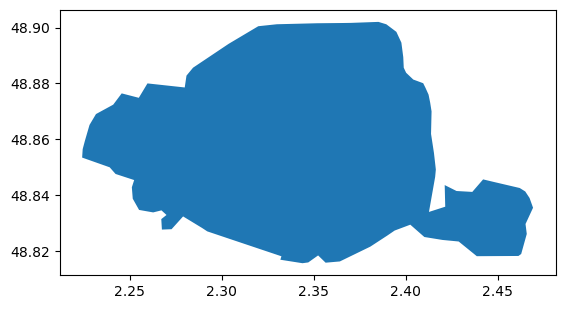

In [35]:
from shapely.ops import unary_union

paris = eu_communes[eu_communes["NUTS_CODE"] == "FR101"].to_crs(4326)
paris_crs = paris.crs
paris = gpd.GeoSeries(unary_union([x for x in paris.geometry]))
paris.crs = paris_crs
cities.append(("Paris",paris))
paris.plot()

<Axes: >

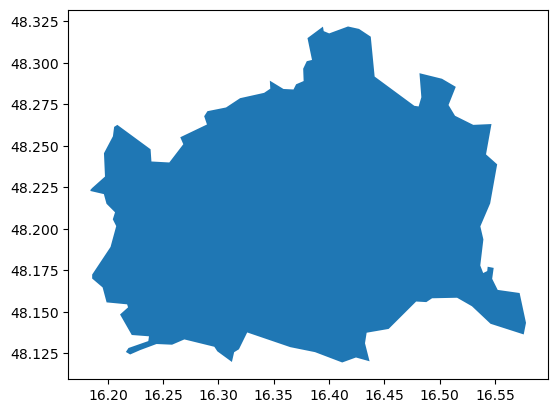

In [36]:
vienna = eu_communes[eu_communes["NUTS_CODE"] == "AT130"].geometry.to_crs(4326)
cities.append(("Vienna",vienna))
vienna.plot()

<Axes: >

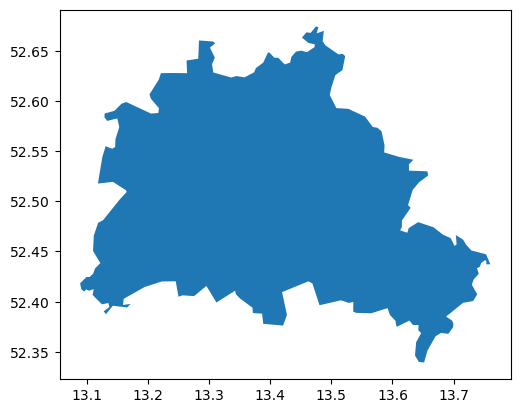

In [ ]:
berlin = eu_communes[eu_communes["NUTS_CODE"] == "DE300"].geometry.to_crs(4326)
# cities.append(("Berlin",berlin))
berlin.plot()

<Axes: >

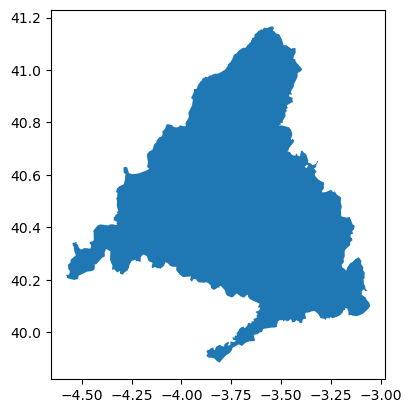

In [37]:
madrid = eu_communes[eu_communes["NUTS_CODE"] == "ES300"].to_crs(4326)
madrid_crs = madrid.crs
madrid_ = [x for x in madrid.geometry]
madrid = gpd.GeoSeries(unary_union([x for x in madrid.geometry])).explode().iloc[[0]]
madrid.crs = madrid_crs
cities.append(("Madrid",madrid))
madrid.plot()

<Axes: >

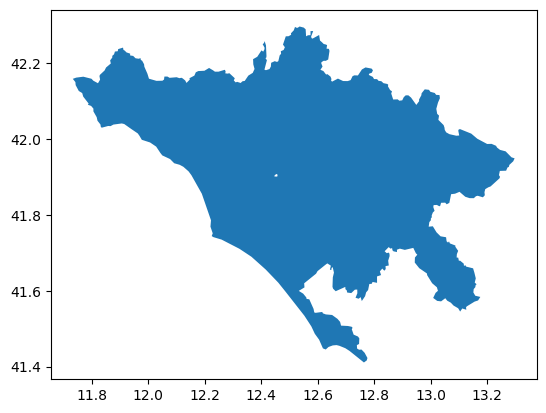

In [38]:
rome = eu_communes[eu_communes["NUTS_CODE"] == "ITI43"].geometry.to_crs(4326)
rome_crs = rome.crs
rome_ = [x for x in rome.geometry]
rome = gpd.GeoSeries(unary_union([x for x in rome.geometry])).explode().iloc[[0]]
rome.crs = rome_crs
cities.append(("Rome",rome))
rome.plot()

In [39]:
ds_cities = []
for capital in cities:
    print(capital[0])
    ds = store.open_data(
        data_id="sentinel-2-l2a",
        bbox=list(capital[1].total_bounds),
        time_range=["2025-07-01", "2025-08-01"],
        spatial_res= 10 / 111320,
        crs="EPSG:4326",
        variables=["b02", "b03", "b04", "b08", "b11", "scl"],
    )

    invalid = [0, 1, 3, 7, 8, 9, 10]  # NO_DATA, SATURATED, CLOUD, etc.
    ds = ds.where(~ds.scl.isin(invalid))
    ds = ds.median(dim="time")
    ds_cities.append(ds)

Paris
Vienna
Madrid
Rome


In [ ]:
# Plot sample July 2025 median RGB composite of Paris

rgb_composite = (
    (ds_cities[0][["b04", "b03", "b02"]].to_dataarray(dim="bands") / 0.25)
    .clip(0, 1)
    .transpose("lat", "lon", "bands")
).compute()

rgb_composite.plot.imshow()

In [12]:
import xvec

aggregated = ds_cities[0].xvec.zonal_stats(
    cities[0], x_coords="lon", y_coords="lat", stats="mean", method="iterate"
)
aggregated

<xarray.Dataset> Size: 68B
Dimensions:      (geometry: 1, time: 1)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-18T10:56:51.024000
    spatial_ref  int64 8B 0
  * geometry     (geometry) object 8B POLYGON ((2.3013155001705665 48.8251259...
Data variables:
    b02          (geometry, time) float64 8B dask.array<chunksize=(1, 1), meta=np.ndarray>
    b03          (geometry, time) float64 8B dask.array<chunksize=(1, 1), meta=np.ndarray>
    b04          (geometry, time) float64 8B dask.array<chunksize=(1, 1), meta=np.ndarray>
    b08          (geometry, time) float64 8B dask.array<chunksize=(1, 1), meta=np.ndarray>
    b11          (geometry, time) float64 8B dask.array<chunksize=(1, 1), meta=np.ndarray>
    scl          (geometry, time) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
Indexes:
    geometry  GeometryIndex (crs=EPSG:4326)
Attributes: (4)

In [13]:
reproject_bbox(rome.total_bounds, "EPSG:4326", "EPSG:32632")

(725366.3728067059, 4587978.893193658, 859114.661140339, 4691586.285039658)

In [11]:
from xcube.core.store import new_data_store
from xcube_eopf.utils import reproject_bbox

store = new_data_store("eopf-zarr")

rome_bbox = [725857.930974692, 4591210.112601308, 856131.4707222998, 4688696.5155386105]
ds_rome = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=rome_bbox,
    time_range=["2025-06-18", "2025-06-19"],
    spatial_res=10,
    crs="EPSG:32632",
    variables=["b02", "b03", "b04", "b08", "b11", "scl"],
)
ds_rome

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 1, x: 13029, y: 9749)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-18T10:00:41.025000
    spatial_ref  int64 8B ...
  * x            (x) float64 104kB 7.259e+05 7.259e+05 ... 8.561e+05 8.561e+05
  * y            (y) float64 78kB 4.689e+06 4.689e+06 ... 4.591e+06 4.591e+06
Data variables:
    b02          (time, y, x) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b11          (time, y, x) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, y, x) uint8 127MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (4)

In [12]:
from xcube.core.store import new_data_store
from xcube_eopf.utils import reproject_bbox

store = new_data_store("eopf-zarr")

rome_bbox = [800000, 4590000, 801000, 4591000]
ds_rome = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=rome_bbox,
    time_range=["2025-06-18", "2025-06-19"],
    spatial_res=10,
    crs="EPSG:32632",
    variables=["b02", "b03", "b04", "b08", "b11", "scl"],
)
ds_rome

<xarray.Dataset> Size: 412kB
Dimensions:      (time: 1, x: 100, y: 100)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-18T10:00:41.025000
    spatial_ref  int64 8B ...
  * x            (x) float64 800B 8e+05 8e+05 8e+05 ... 8.01e+05 8.01e+05
  * y            (y) float64 800B 4.591e+06 4.591e+06 ... 4.59e+06 4.59e+06
Data variables:
    b02          (time, y, x) float64 80kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    b03          (time, y, x) float64 80kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    b04          (time, y, x) float64 80kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    b08          (time, y, x) float64 80kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    b11          (time, y, x) float64 80kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    scl          (time, y, x) uint8 10kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
Attributes: (4)

In [ ]:
from xcube.core.store import new_data_store
from xcube_eopf.utils import reproject_bbox

store = new_data_store("eopf-zarr")

rome_bbox = [
    11.733843999456301,
    41.410892132073776,
    13.296299499686363,
    42.29599449465578,
]
ds_rome = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=rome_bbox,
    time_range=["2025-06-18", "2025-06-19"],
    spatial_res=10,
    crs="EPSG:4326",
    variables=["b02", "b03", "b04", "b08", "b11", "scl"],
)
ds_rome

/home/mclaus@eurac.edu/micromamba/envs/eopf-zarr3/lib/python3.11/site-packages/xarray_sentinel/esa_safe.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<xarray.Dataset> Size: 7GB
Dimensions:      (time: 1, lon: 17395, lat: 9854)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-18T10:00:41.025000
    spatial_ref  int64 8B 0
  * lon          (lon) float64 139kB 11.73 11.73 11.73 11.73 ... 13.3 13.3 13.3
  * lat          (lat) float64 79kB 42.3 42.3 42.3 42.3 ... 41.41 41.41 41.41
Data variables:
    b02          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b11          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, lat, lon) uint8 171MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (4)

In [85]:
ds_rome = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=list(rome.to_crs("EPSG:3035").total_bounds),
    time_range=["2025-06-18", "2025-06-19"],
    spatial_res=10,
    crs="EPSG:3035",
    variables=["b02", "b03", "b04", "b08", "b11", "scl"],
)
ds_rome

AttributeError: 'dict' object has no attribute 'coords'

In [5]:
wien = eu_communes.loc[eu_communes["COMM_NAME"] == "Wien"].geometry
wien_4326 = wien.to_crs(4326)

In [ ]:
# wien_4326 = wien_4326.buffer(0.2)

/tmp/ipykernel_2938064/3869857321.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  wien_4326 = wien_4326.buffer(0.2)


In [13]:
bbox_utm = list(wien_4326.to_crs(32633).total_bounds)
# bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

In [14]:
bbox_utm

[573099.931571348, 5308232.610378701, 632256.6386225757, 5375260.203465267]

In [16]:
wien_4326.to_crs(32633)

2194    POLYGON ((573288.493 5335931.509, 573331.706 5...
dtype: geometry

In [34]:
# bbox = [10.6, 46.74, 11, 46.91]
# crs_utm = "EPSG:32632"
# bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

In [15]:
ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox_utm,
    time_range=["2025-06-18", "2025-06-19"],
    spatial_res=10,
    crs=crs_utm,
    variables=["b02", "b03", "b04", "b08", "b11", "scl"],
)
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 1, y: 6704, x: 5917)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-18T11:00:41.025000
    spatial_ref  int64 8B ...
  * x            (x) float64 47kB 5.731e+05 5.731e+05 ... 6.322e+05 6.323e+05
  * y            (y) float64 54kB 5.375e+06 5.375e+06 ... 5.308e+06 5.308e+06
Data variables:
    b02          (time, y, x) float64 317MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 317MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 317MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 317MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b11          (time, y, x) float64 317MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, y, x) uint8 40MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (4)

In [12]:
wien.values

<GeometryArray>
[<POLYGON ((4780681.63 2803583.508, 4781760.92 2805531.814, 4782028.038 28069...>]
Length: 1, dtype: geometry

In [22]:
import xvec

aggregated = ds.xvec.zonal_stats(
    wien.to_crs(32633), x_coords="x", y_coords="y", stats="mean", method="iterate"
)
aggregated.b02.values

array([[0.07378825]])

In [37]:
wien

2194    POLYGON ((4780681.63 2803583.508, 4781760.92 2...
Name: geometry, dtype: geometry

(False_Color_SNOW)=
## False Color Composite Visualization

Let's **visualize a false color composite** (R: SWIR, G: NIR, B: RED) and the classic RGB side by side.  
In this case, you can notice that false color composite enhances the visibility of snow-covered areas compared to clouds.  
Before the visualization, we rescale the data to improve the visibility.

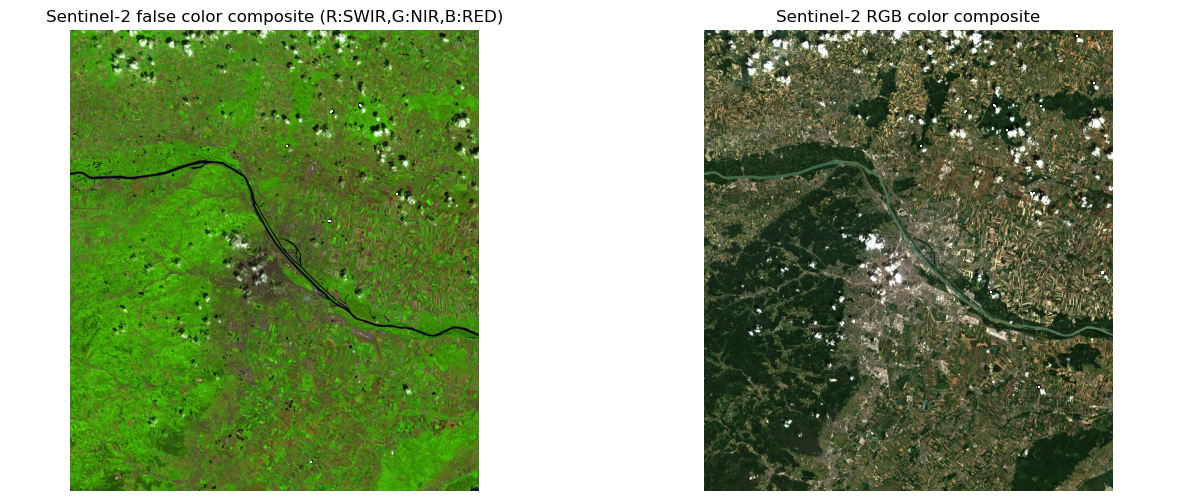

In [36]:
false_color_composite = (
    (ds[["b11", "b08", "b04"]].to_dataarray(dim="bands") / 0.7)
    .clip(0, 1)
    .squeeze("time")
    .transpose("y", "x", "bands")
)
rgb_composite = (
    (ds[["b04", "b03", "b02"]].to_dataarray(dim="bands") / 0.25)
    .clip(0, 1)
    .squeeze("time")
    .transpose("y", "x", "bands")
)

fig, ax = plt.subplots(figsize=(15, 6))
ax.axis("off")
plt.subplot(121)
plt.axis("off")
plt.title("Sentinel-2 false color composite (R:SWIR,G:NIR,B:RED)")
plt.imshow(false_color_composite)
plt.subplot(122)
plt.axis("off")
plt.title("Sentinel-2 RGB color composite")
plt.imshow(rgb_composite)

(CLOUD_SNOW)=
## Cloud Masking

As usual, we mask out the clouds before proceeding in our snow mapping workflow.

In [6]:
valid_mask = np.logical_not(ds["scl"].isin([8, 9, 3]))

ds_valid = ds.where(valid_mask)

false_color_composite_masked = false_color_composite.where(valid_mask[0])

(NDSI_SNOW)=
## NDSI Computation

 ❄️ To rapidly classify snow-covered areas, we calculate the Normalized Difference Snow Index (NDSI) using the shortwave infrared (SWIR) and green bands:

$$NDSI=\frac {GREEN-SWIR}{GREEN+SWIR}$$ 

This normalized difference highlights snow by taking advantage of its high reflectance in the green band and strong absorption in the SWIR band.

In [7]:
green = ds_valid["b03"]
swir = ds_valid["b11"]

ndsi = (green - swir) / (green + swir)

snow_map = ndsi > 0.42

snow_map

<xarray.DataArray (time: 1, y: 1960, x: 3095)> Size: 6MB
dask.array<gt, shape=(1, 1960, 3095), dtype=bool, chunksize=(1, 1830, 1830), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-19T10:15:59.024000
    spatial_ref  int64 8B 0
  * x            (x) float64 25kB 6.218e+05 6.219e+05 ... 6.528e+05 6.528e+05
  * y            (y) float64 16kB 5.197e+06 5.197e+06 ... 5.178e+06 5.178e+06

(Snow_Map_SNOW)=
## Snow Map Visualization

Let's visualize the classification output and compare it with the cloud-masked false color composite.

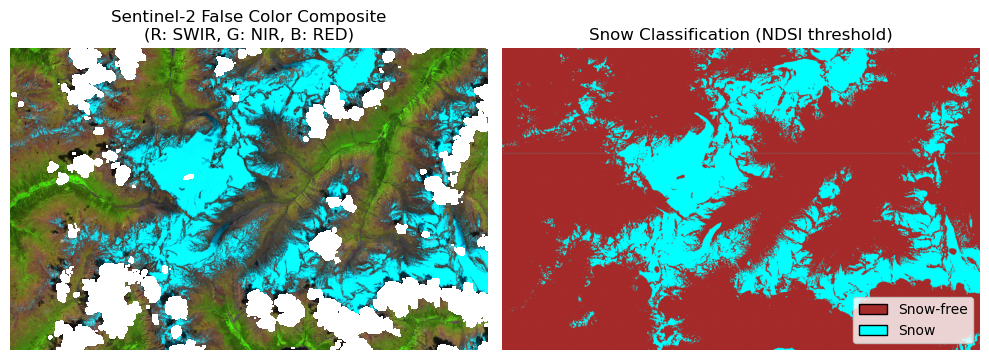

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot RGB image
axes[0].imshow(false_color_composite_masked)
axes[0].axis("off")
axes[0].set_title("Sentinel-2 False Color Composite\n(R: SWIR, G: NIR, B: RED)")

# Plot binary snow classification
binary_data = snow_map.squeeze("time")

# Define discrete colormap: 0 = no snow (light gray), 1 = snow (blue)
cmap = ListedColormap(["brown", "cyan"])

im = axes[1].imshow(binary_data, cmap=cmap)
axes[1].axis("off")
axes[1].set_title("Snow Classification (NDSI threshold)")

# Create custom legend
legend_elements = [
    Patch(facecolor="brown", edgecolor="k", label="Snow-free"),
    Patch(facecolor="cyan", edgecolor="k", label="Snow"),
]

axes[1].legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

Finally, let's compare our snow map with the Scene Classification Layer (SCL) shipped with the Sentinel-2 L2A data:

In [9]:
scl_snow_ice_map = ds.scl == 11
scl_snow_ice_map

<xarray.DataArray 'scl' (time: 1, y: 1960, x: 3095)> Size: 6MB
dask.array<eq, shape=(1, 1960, 3095), dtype=bool, chunksize=(1, 1830, 1830), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-06-19T10:15:59.024000
    spatial_ref  int64 8B ...
  * x            (x) float64 25kB 6.218e+05 6.219e+05 ... 6.528e+05 6.528e+05
  * y            (y) float64 16kB 5.197e+06 5.197e+06 ... 5.178e+06 5.178e+06

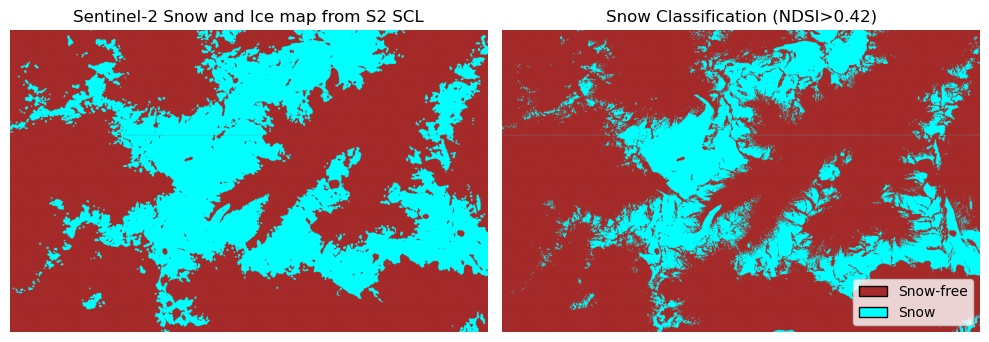

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Define discrete colormap: 0 = no snow (light gray), 1 = snow (blue)
cmap = ListedColormap(["brown", "cyan"])

# Plot SCL Snow and Ice map
axes[0].imshow(scl_snow_ice_map.squeeze("time"), cmap=cmap)
axes[0].axis("off")
axes[0].set_title("Sentinel-2 Snow and Ice map from S2 SCL")

# Plot binary snow classification
binary_data = snow_map.squeeze("time")

im = axes[1].imshow(binary_data, cmap=cmap)
axes[1].axis("off")
axes[1].set_title("Snow Classification (NDSI>0.42)")

# Create custom legend
legend_elements = [
    Patch(facecolor="brown", edgecolor="k", label="Snow-free"),
    Patch(facecolor="cyan", edgecolor="k", label="Snow"),
]

axes[1].legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

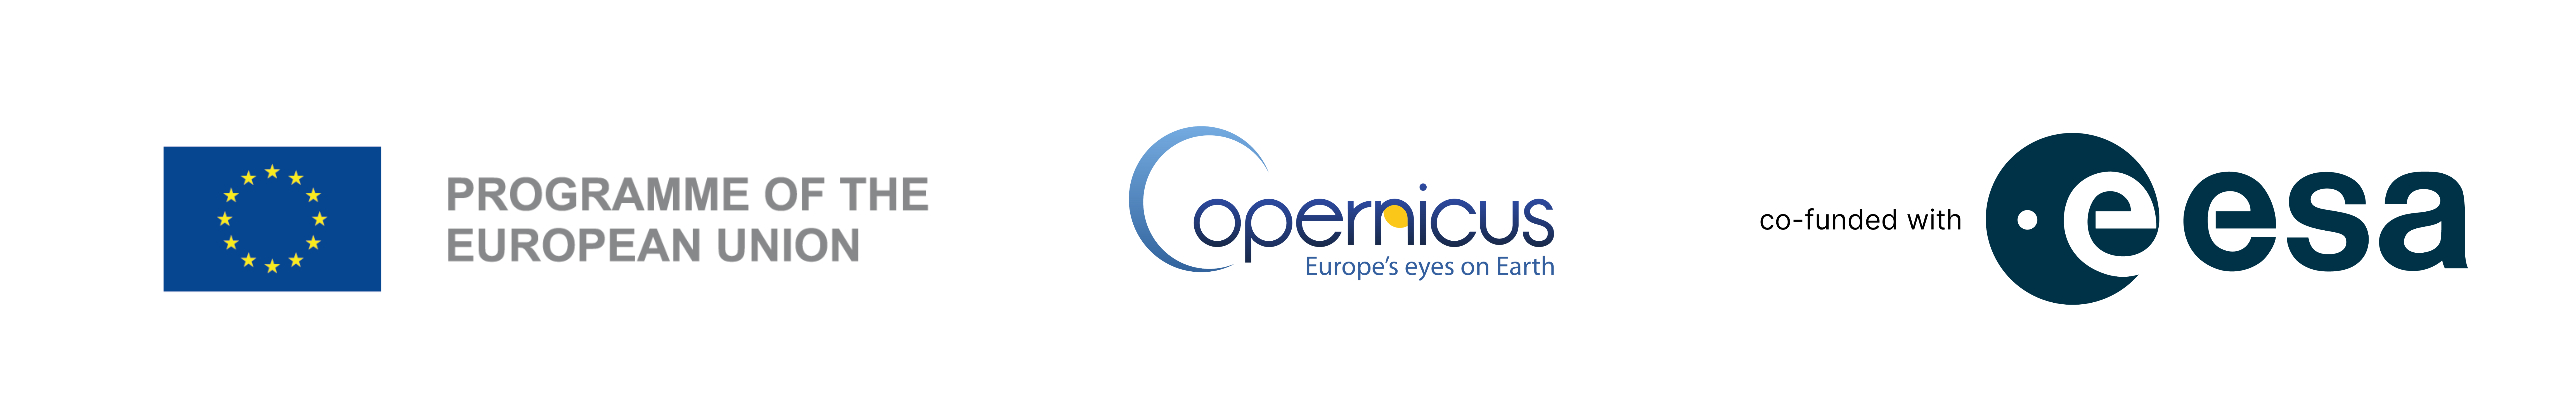